In [11]:
#Cell 1: Import Libraries:

# ============================================================
# 🏥 PATIENT HEALTH RISK PREDICTOR
# Pima Indians Diabetes Dataset
# Built by: Kartik | Munich | 2025
# Goal: Predict diabetes risk from patient health measurements
# ============================================================

#Core libraries:
import numpy as np
import pandas as pd 

#visualisation:
import matplotlib.pyplot as plt 
import seaborn as sns 

#Machine learning:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score)

#Settings:
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

print("✅ All libraries imported successfully!")
print("🏥 Patient Health Risk Predictor is ready!")


✅ All libraries imported successfully!
🏥 Patient Health Risk Predictor is ready!


In [12]:
# ============================================================
# CELL 2: Load the Diabetes Dataset
# ============================================================

#Load the data
df = pd.read_csv('diabetes.csv')

#First look
print("PIMA INDIANS DIABETES DATASET")
print("="*50)
print(f"Total patients:  {df.shape[0]}")
print(f" Total features:  {df.shape[1]}")
print("="*50)

#Column names
print("\n  WHAT EACH COLUMN MEANS:")
columns_explained = {
    'Pregnancies'             : 'Number of times pregnant',
    'Glucose'                 : 'Plasma glucose concentration',
    'BloodPressure'           : 'Diastolic blood pressure (mm Hg)',
    'SkinThickness'           : 'Triceps skin fold thickness (mm)',
    'Insulin'                 : '2-Hour serum insulin (mu U/ml)',
    'BMI'                     : 'Body mass index (weight/height²)',
    'DiabetesPedigreeFunction': 'Diabetes hereditary likelihood score',
    'Age'                     : 'Age in years',
    'Outcome'                 : '🎯 TARGET: 1=Diabetic, 0=Not Diabetic'
}
for col, meaning in columns_explained.items():
    print(f"  {col:25} -> {meaning}")

#Target breakdown
print("\n OUTCOME BREAKDOWN:")
print(df['Outcome'].value_counts())
print(f"\n Diabetic (1):  {df['Outcome'].sum()}   ({df['Outcome'].mean()*100:.1f}%)")
print(f"  Not Diabetic (0): {(df['Outcome']==0).sum()}  ({(1-df['Outcome'].mean())*100:.1f}%)")

#First 5 rows:
print("\n First 5 rows:")
print(df.head()) 

PIMA INDIANS DIABETES DATASET
Total patients:  768
 Total features:  9

  WHAT EACH COLUMN MEANS:
  Pregnancies               -> Number of times pregnant
  Glucose                   -> Plasma glucose concentration
  BloodPressure             -> Diastolic blood pressure (mm Hg)
  SkinThickness             -> Triceps skin fold thickness (mm)
  Insulin                   -> 2-Hour serum insulin (mu U/ml)
  BMI                       -> Body mass index (weight/height²)
  DiabetesPedigreeFunction  -> Diabetes hereditary likelihood score
  Age                       -> Age in years
  Outcome                   -> 🎯 TARGET: 1=Diabetic, 0=Not Diabetic

 OUTCOME BREAKDOWN:
Outcome
0    500
1    268
Name: count, dtype: int64

 Diabetic (1):  268   (34.9%)
  Not Diabetic (0): 500  (65.1%)

 First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29  

HEALTH DATA EXPLORATION

📊 AVERAGE MEASUREMENTS — Diabetic vs Not Diabetic:
   Feature                   Not Diabetic    Diabetic        Difference
------------------------------------------------------------
   Glucose                       109.98      141.26+28.4%
   BMI                            30.30       35.14+16.0%
   Age                            31.19       37.07+18.8%
   BloodPressure                  68.18       70.82+3.9%
   Insulin                        68.79      100.34+45.9%
   DiabetesPedigreeFunction        0.43        0.55+28.1%


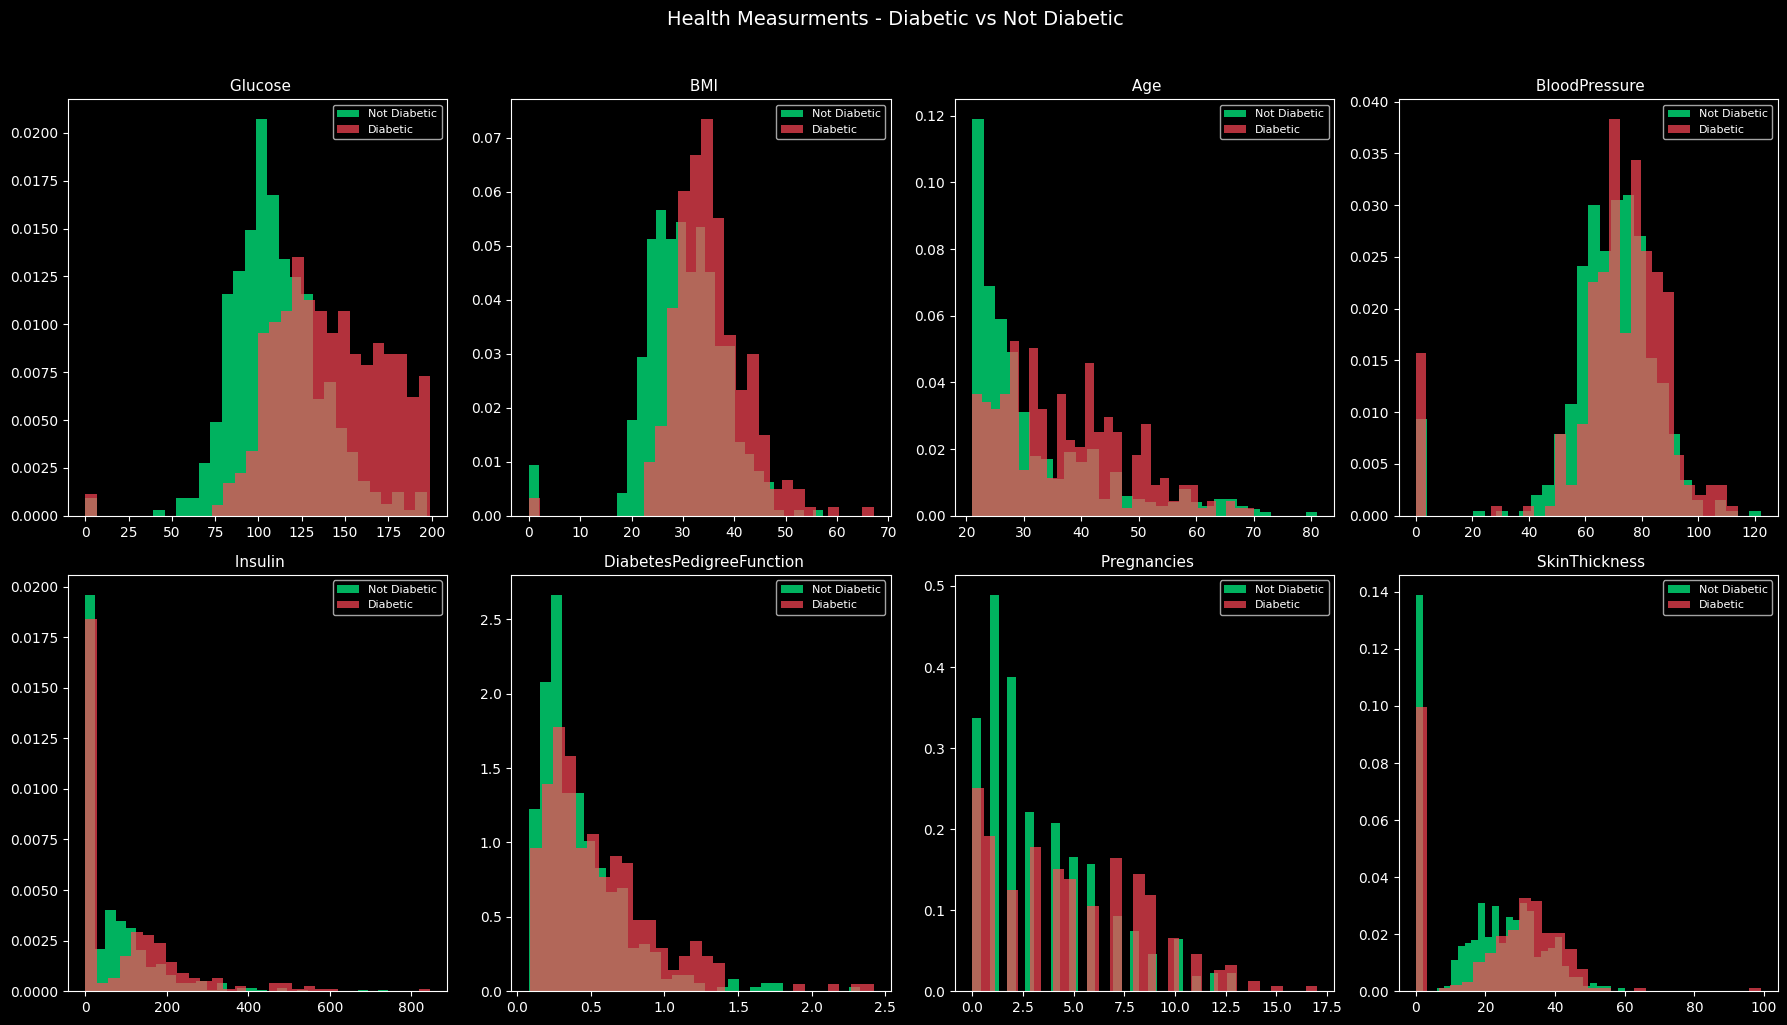


 CORRELATION WITH DIABETIC RISK:
   Glucose                   +0.467  ↑ increases risk  ██████████████████
   BMI                       +0.293  ↑ increases risk  ███████████
   Age                       +0.238  ↑ increases risk  █████████
   Pregnancies               +0.222  ↑ increases risk  ████████
   DiabetesPedigreeFunction  +0.174  ↑ increases risk  ██████
   Insulin                   +0.131  ↑ increases risk  █████
   SkinThickness             +0.075  ↑ increases risk  ██
   BloodPressure             +0.065  ↑ increases risk  ██


In [13]:
# ============================================================
# CELL 3: Explore the Data
# ============================================================

print("HEALTH DATA EXPLORATION")
print("="*50)

#Key statistics by outcome
print("\n📊 AVERAGE MEASUREMENTS — Diabetic vs Not Diabetic:")
print("=" * 60)
print(f"   {'Feature':25} {'Not Diabetic':15} {'Diabetic':15} {'Difference'}")
print("-" * 60)

features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']
for feat in features:
    not_diab = df[df['Outcome']==0][feat].mean()
    diab = df[df['Outcome']==1][feat].mean()
    diff = ((diab - not_diab) / not_diab * 100)
    print(f"   {feat:25} {not_diab:10.2f}  {diab:10.2f}{diff:+.1f}%")

#visualise:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

features_all = ['Glucose', 'BMI', 'Age', 'BloodPressure',
                'Insulin', 'DiabetesPedigreeFunction',
                'Pregnancies', 'SkinThickness']

for i, feat in enumerate(features_all):
    axes[i].hist(df[df['Outcome']==0][feat], bins=30,
                 alpha=0.7, color='#00ff88',label='Not Diabetic', density=True)
    axes[i].hist(df[df['Outcome']==1][feat], bins=30,
                 alpha=0.7, color='#ff4757',
                 label='Diabetic', density=True)
    axes[i].set_title(f' {feat}', fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Health Measurments - Diabetic vs Not Diabetic',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#Correlation with diabetic:
print("\n CORRELATION WITH DIABETIC RISK:")
print("="*50)
corr = df.corr()['Outcome'].sort_values(ascending=False)
for col, val in corr.items():
    if col != 'Outcome':
        bar = '█' * int(abs(val) * 40)
        direction = '↑ increases' if val > 0 else '↓ decreases'
        print(f"   {col:25} {val:+.3f}  {direction} risk  {bar}")

In [14]:
# ============================================================
# CELL 4: Handle Zeros & Prepare Data
# ============================================================

print("DATA PREPARATION")
print("="*50)

# Check for impossible zero values
# (you can't have 0 glucose, 0 BMI, 0 blood pressure!)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI']

print("\n IMPOSSIBLE ZERO VALUES:")
print("=" * 50)
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"   {col:25}  {zeros:4d}  zeros ({pct:.1f}%)")

#Replace zeros with median (they are actually missing values!)
print("\n Replacing zeros with median values....")
for col in zero_cols:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)
    print(f"   {col:25} median = {median_val:.2f}")


#Separate features and target:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"\n📊 Features (X): {X.shape}")
print(f"🎯 Target   (y): {y.shape}")
print(f"   Diabetic:     {y.sum()} ({y.mean()*100:.1f}%)")
print(f"   Not Diabetic: {(y==0).sum()} ({(1-y.mean())*100:.1f}%)")


#Train/Test Split:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✂️  TRAIN/TEST SPLIT:")
print(f"   Training patients: {X_train.shape[0]}")
print(f"   Testing patients:  {X_test.shape[0]}")

#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

print(f"\n✅ Features scaled!")
print(f"   Mean: {X_train_scaled.mean():.6f}")
print(f"   Std:  {X_train_scaled.std():.6f}")
print("\n🚀 Data ready for ML!")

DATA PREPARATION

 IMPOSSIBLE ZERO VALUES:
   Glucose                       5  zeros (0.7%)
   BloodPressure                35  zeros (4.6%)
   SkinThickness               227  zeros (29.6%)
   Insulin                     374  zeros (48.7%)
   BMI                          11  zeros (1.4%)

 Replacing zeros with median values....
   Glucose                   median = 117.00
   BloodPressure             median = 72.00
   SkinThickness             median = 29.00
   Insulin                   median = 125.00
   BMI                       median = 32.30

📊 Features (X): (768, 8)
🎯 Target   (y): (768,)
   Diabetic:     268 (34.9%)
   Not Diabetic: 500 (65.1%)

✂️  TRAIN/TEST SPLIT:
   Training patients: 614
   Testing patients:  154

✅ Features scaled!
   Mean: -0.000000
   Std:  1.000000

🚀 Data ready for ML!


In [15]:
# ============================================================
# CELL 5: Train 3 Models
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'),
    'KNN': KNeighborsClassifier(
        n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight='balanced'),
}

results = {}

print("🚀 TRAINING HEALTH RISK MODELS...")
print("=" * 60)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred    = model.predict(X_test_scaled)

    # Scores
    acc       = accuracy_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test,
                model.predict_proba(X_test_scaled)[:,1])
    cv        = cross_val_score(model, X_train_scaled,
                y_train, cv=5, scoring='recall')

    results[name] = {
        'acc': acc, 'recall': recall,
        'precision': precision,
        'f1': f1, 'auc': auc,
        'cv_recall': cv.mean(),
        'y_pred': y_pred
    }

    print(f"\n🏥 {name}")
    print(f"   Accuracy:   {acc*100:.2f}%")
    print(f"   Recall:     {recall*100:.2f}%  ← Catching diabetic patients!")
    print(f"   Precision:  {precision*100:.2f}%")
    print(f"   F1 Score:   {f1*100:.2f}%")
    print(f"   AUC:        {auc:.3f}")
    print(f"   CV Recall:  {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")

print("\n" + "=" * 60)

# Best by Recall — medical context!
best = max(results, key=lambda x: results[x]['recall'])
print(f"\n🏆 BEST MODEL (by Recall): {best}")
print(f"   Recall:    {results[best]['recall']*100:.2f}%")
print(f"   Precision: {results[best]['precision']*100:.2f}%")
print(f"   F1:        {results[best]['f1']*100:.2f}%")
print(f"   AUC:       {results[best]['auc']:.3f}")
print(f"\n💡 WHY RECALL MATTERS IN MEDICINE:")
print(f"   Missing a diabetic patient = no treatment = serious harm!")
print(f"   False alarm = extra tests = minor inconvenience only")

🚀 TRAINING HEALTH RISK MODELS...

🏥 Logistic Regression
   Accuracy:   73.38%
   Recall:     70.37%  ← Catching diabetic patients!
   Precision:  60.32%
   F1 Score:   64.96%
   AUC:        0.813
   CV Recall:  70.11% ± 3.27%

🏥 KNN
   Accuracy:   75.32%
   Recall:     61.11%  ← Catching diabetic patients!
   Precision:  66.00%
   F1 Score:   63.46%
   AUC:        0.789
   CV Recall:  57.49% ± 6.24%

🏥 Decision Tree
   Accuracy:   72.73%
   Recall:     61.11%  ← Catching diabetic patients!
   Precision:  61.11%
   F1 Score:   61.11%
   AUC:        0.771
   CV Recall:  73.41% ± 8.30%


🏆 BEST MODEL (by Recall): Logistic Regression
   Recall:    70.37%
   Precision: 60.32%
   F1:        64.96%
   AUC:       0.813

💡 WHY RECALL MATTERS IN MEDICINE:
   Missing a diabetic patient = no treatment = serious harm!
   False alarm = extra tests = minor inconvenience only


🏥 CONFUSION MATRIX: Logistic Regression

   ✅ True Positives  (diabetic correctly caught):  38
   ✅ True Negatives  (healthy correctly cleared):  75
   ⚠️  False Positives (healthy flagged as diabetic): 25
   🚨 False Negatives (diabetic MISSED!):            16

💊 MEDICAL MEANING:
   38 diabetic patients caught → sent for treatment ✅
   16 diabetic patients MISSED → no treatment! 🚨
   25 healthy patients flagged → extra tests ⚠️

   Catch rate: 70.37% of diabetic patients
   Miss rate:  29.63% of diabetic patients


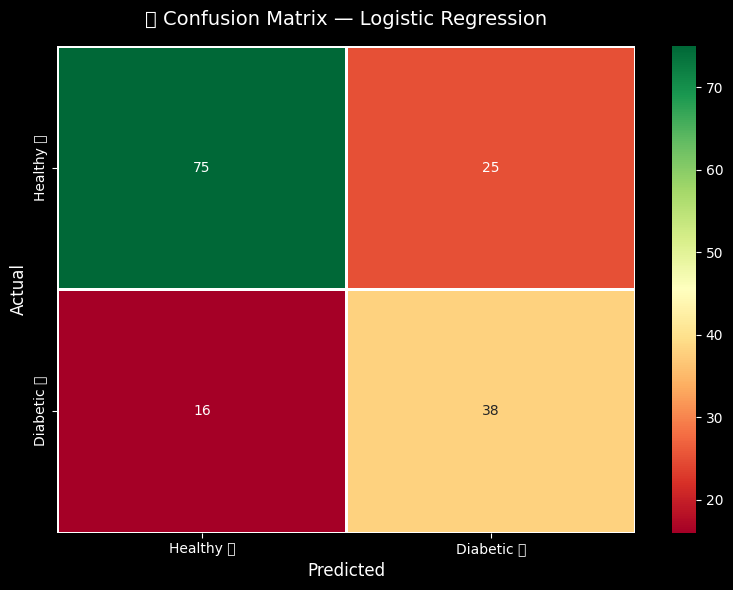


📋 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Healthy       0.82      0.75      0.79       100
    Diabetic       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [16]:
# ============================================================
# CELL 6: Confusion Matrix — Medical Deep Dive
# ============================================================

best_model  = models[best]
y_pred_best = results[best]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"🏥 CONFUSION MATRIX: {best}")
print("=" * 60)
print(f"\n   ✅ True Positives  (diabetic correctly caught):  {tp}")
print(f"   ✅ True Negatives  (healthy correctly cleared):  {tn}")
print(f"   ⚠️  False Positives (healthy flagged as diabetic): {fp}")
print(f"   🚨 False Negatives (diabetic MISSED!):            {fn}")
print("=" * 60)
print(f"\n💊 MEDICAL MEANING:")
print(f"   {tp} diabetic patients caught → sent for treatment ✅")
print(f"   {fn} diabetic patients MISSED → no treatment! 🚨")
print(f"   {fp} healthy patients flagged → extra tests ⚠️")
print(f"\n   Catch rate: {tp/(tp+fn)*100:.2f}% of diabetic patients")
print(f"   Miss rate:  {fn/(tp+fn)*100:.2f}% of diabetic patients")

# Visualise
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Healthy ✅', 'Diabetic 💊'],
            yticklabels=['Healthy ✅', 'Diabetic 💊'],
            linewidths=2)
plt.title(f'🏥 Confusion Matrix — {best}', fontsize=14, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Full report
print(f"\n📋 FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_best,
      target_names=['Healthy', 'Diabetic']))

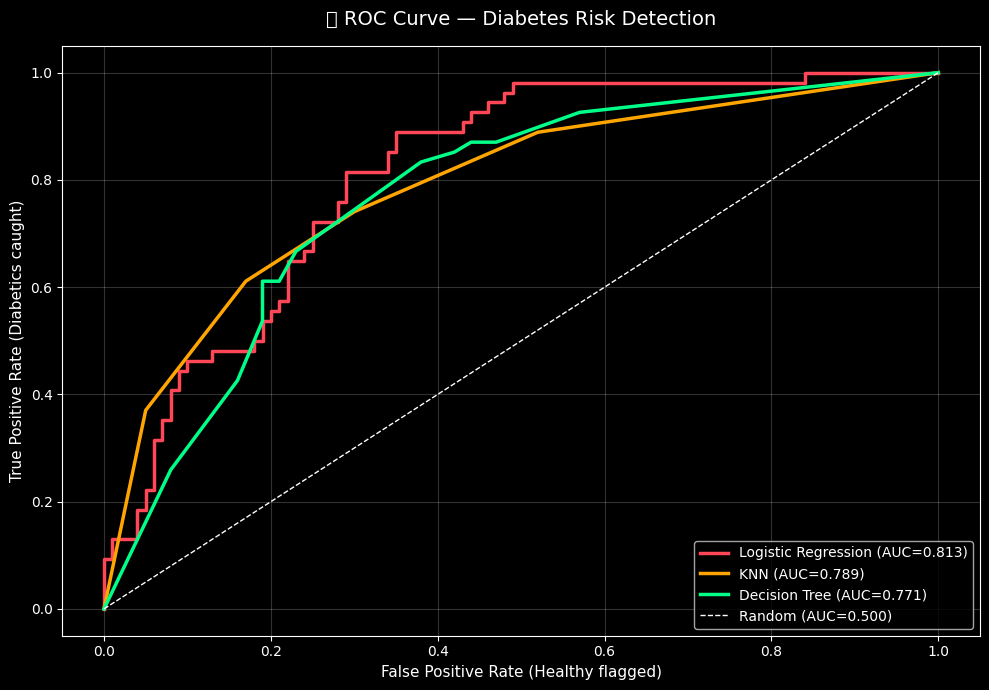

📊 AUC SCORES:
   Logistic Regression       AUC: 0.813  ✅ Very Good
   KNN                       AUC: 0.789  👍 Good
   Decision Tree             AUC: 0.771  👍 Good


In [17]:
# ============================================================
# CELL 7: ROC Curve — All 3 Models
# ============================================================
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))
colors = ['#ff4757', '#ffa502', '#00ff88']

for (name, result), color in zip(results.items(), colors):
    model  = models[name]
    probs  = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc    = result['auc']
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'white', linewidth=1,
         linestyle='--', label='Random (AUC=0.500)')

plt.title('🏥 ROC Curve — Diabetes Risk Detection', fontsize=14, pad=15)
plt.xlabel('False Positive Rate (Healthy flagged)', fontsize=11)
plt.ylabel('True Positive Rate (Diabetics caught)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("📊 AUC SCORES:")
print("=" * 50)
for name, result in results.items():
    auc = result['auc']
    if auc >= 0.85:
        grade = "⭐ Excellent!"
    elif auc >= 0.80:
        grade = "✅ Very Good"
    elif auc >= 0.75:
        grade = "👍 Good"
    else:
        grade = "⚠️  Needs work"
    print(f"   {name:25} AUC: {auc:.3f}  {grade}")

🏥 WHAT PREDICTS DIABETES RISK?
    1. Glucose                        0.4710  █████████████████████████████████████
    2. BMI                            0.1957  ███████████████
    3. Age                            0.1087  ████████
    4. Insulin                        0.0803  ██████
    5. DiabetesPedigreeFunction       0.0691  █████
    6. SkinThickness                  0.0438  ███
    7. Pregnancies                    0.0314  ██
    8. BloodPressure                  0.0000  


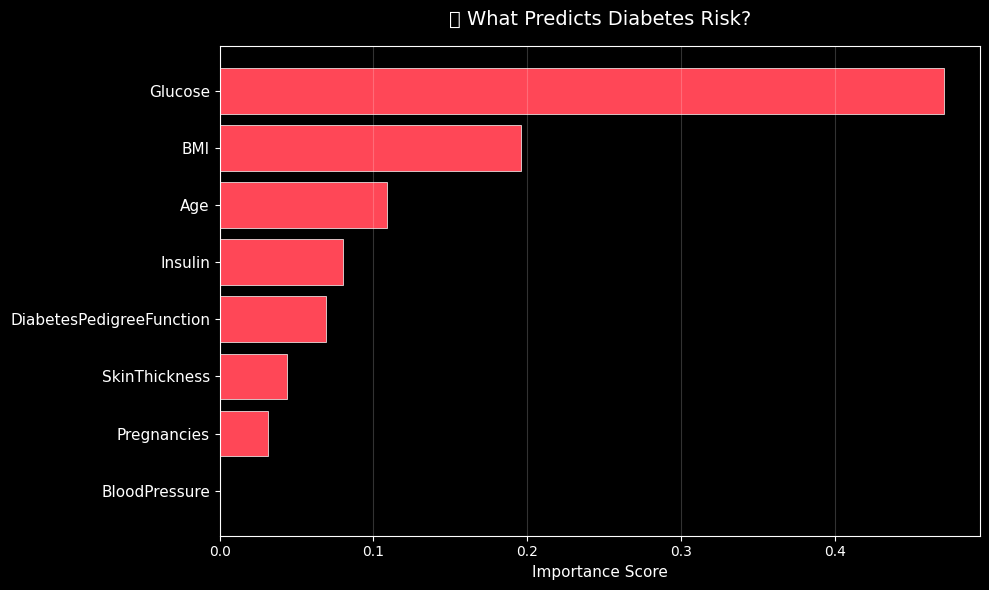


💊 MEDICAL INTERPRETATION:
   Glucose                      (0.4710) → High blood sugar → #1 diabetes indicator
   BMI                          (0.1957) → Obesity strongly linked to Type 2 diabetes
   Age                          (0.1087) → Risk increases significantly with age
   DiabetesPedigreeFunction     (0.0691) → Family history → genetic risk factor
   Insulin                      (0.0803) → Insulin resistance → key diabetes marker
   BloodPressure                (0.0000) → Hypertension often co-occurs with diabetes
   Pregnancies                  (0.0314) → Gestational diabetes history increases risk
   SkinThickness                (0.0438) → Body fat indicator linked to insulin resistance


In [18]:
# ============================================================
# CELL 8: Feature Importance — What Causes Diabetes?
# ============================================================

# Use Decision Tree for feature importance
dt_model     = models['Decision Tree']
importances  = dt_model.feature_importances_
feature_names= X.columns
indices      = np.argsort(importances)[::-1]

print("🏥 WHAT PREDICTS DIABETES RISK?")
print("=" * 60)
for i, idx in enumerate(indices):
    bar = '█' * int(importances[idx] * 80)
    print(f"   {i+1:2}. {feature_names[idx]:30} "
          f"{importances[idx]:.4f}  {bar}")

# Visualise
plt.figure(figsize=(10, 6))
plt.barh(
    range(len(indices)),
    importances[indices][::-1],
    color='#ff4757',
    edgecolor='white',
    linewidth=0.5
)
plt.yticks(
    range(len(indices)),
    [feature_names[indices[len(indices)-1-i]]
     for i in range(len(indices))],
    fontsize=11
)
plt.xlabel('Importance Score', fontsize=11)
plt.title('🏥 What Predicts Diabetes Risk?', fontsize=14, pad=15)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print("\n💊 MEDICAL INTERPRETATION:")
medical_meaning = {
    'Glucose'                 : 'High blood sugar → #1 diabetes indicator',
    'BMI'                     : 'Obesity strongly linked to Type 2 diabetes',
    'Age'                     : 'Risk increases significantly with age',
    'DiabetesPedigreeFunction': 'Family history → genetic risk factor',
    'Insulin'                 : 'Insulin resistance → key diabetes marker',
    'BloodPressure'           : 'Hypertension often co-occurs with diabetes',
    'Pregnancies'             : 'Gestational diabetes history increases risk',
    'SkinThickness'           : 'Body fat indicator linked to insulin resistance',
}
for feat, meaning in medical_meaning.items():
    imp = importances[list(feature_names).index(feat)]
    print(f"   {feat:28} ({imp:.4f}) → {meaning}")

In [19]:
# ============================================================
# CELL 9: Interactive Diabetes Risk Predictor Tool
# ============================================================

def predict_diabetes_risk(glucose, bmi, age,
                           pregnancies=1, insulin=125,
                           dpf=0.47, skin_thickness=29,
                           blood_pressure=72):
    """
    Predict diabetes risk for a patient!

    Parameters:
        glucose      → Blood sugar level (normal: 70-100)
        bmi          → Body Mass Index (normal: 18.5-24.9)
        age          → Patient age in years
        pregnancies  → Number of pregnancies (default 1)
        insulin      → Serum insulin level (default median)
        dpf          → Diabetes family history score
        skin_thickness → Skin fold thickness (default median)
        blood_pressure → Diastolic BP (default median)
    """
    patient = pd.DataFrame([[pregnancies, glucose, blood_pressure,
                              skin_thickness, insulin, bmi, dpf, age]],
                            columns=X.columns)

    patient_scaled = scaler.transform(patient)
    prob           = models['Logistic Regression'].predict_proba(
                     patient_scaled)[0][1]
    prediction     = models['Logistic Regression'].predict(
                     patient_scaled)[0]

    return prob, prediction

# ============================================================
# TEST 4 DIFFERENT PATIENT PROFILES
# ============================================================
print("🏥 DIABETES RISK PREDICTOR")
print("=" * 60)

patients = [
    {
        'name'      : '👨 Young Healthy Male',
        'glucose'   : 85,
        'bmi'       : 22.0,
        'age'       : 25,
        'dpf'       : 0.20,
        'desc'      : 'Low glucose, healthy weight, young, no family history'
    },
    {
        'name'      : '👩 Middle-aged Average',
        'glucose'   : 120,
        'bmi'       : 30.0,
        'age'       : 40,
        'dpf'       : 0.45,
        'desc'      : 'Slightly high glucose, overweight, middle-aged'
    },
    {
        'name'      : '👴 Older High Risk',
        'glucose'   : 160,
        'bmi'       : 38.0,
        'age'       : 58,
        'dpf'       : 0.80,
        'desc'      : 'High glucose, obese, older, strong family history'
    },
    {
        'name'      : '👩 Borderline Case',
        'glucose'   : 105,
        'bmi'       : 27.0,
        'age'       : 35,
        'dpf'       : 0.55,
        'desc'      : 'Normal glucose, slightly overweight, some family history'
    },
]

for p in patients:
    prob, pred = predict_diabetes_risk(
        glucose=p['glucose'],
        bmi=p['bmi'],
        age=p['age'],
        dpf=p.get('dpf', 0.47)
    )

    risk_level = (
        "🟢 LOW RISK"    if prob < 0.3  else
        "🟡 MEDIUM RISK" if prob < 0.6  else
        "🔴 HIGH RISK"
    )

    print(f"\n{p['name']}")
    print(f"   Description  : {p['desc']}")
    print(f"   Glucose      : {p['glucose']}  |  BMI: {p['bmi']}  |  Age: {p['age']}")
    print(f"   Diabetes Prob: {prob*100:.1f}%")
    print(f"   Risk Level   : {risk_level}")
    print(f"   Prediction   : {'💊 Diabetic' if pred==1 else '✅ Not Diabetic'}")

print("\n" + "=" * 60)
print("💡 DISCLAIMER:")
print("   This is an ML model for educational purposes only!")
print("   Always consult a real doctor for medical decisions!")
print("=" * 60)

🏥 DIABETES RISK PREDICTOR

👨 Young Healthy Male
   Description  : Low glucose, healthy weight, young, no family history
   Glucose      : 85  |  BMI: 22.0  |  Age: 25
   Diabetes Prob: 3.0%
   Risk Level   : 🟢 LOW RISK
   Prediction   : ✅ Not Diabetic

👩 Middle-aged Average
   Description  : Slightly high glucose, overweight, middle-aged
   Glucose      : 120  |  BMI: 30.0  |  Age: 40
   Diabetes Prob: 30.8%
   Risk Level   : 🟡 MEDIUM RISK
   Prediction   : ✅ Not Diabetic

👴 Older High Risk
   Description  : High glucose, obese, older, strong family history
   Glucose      : 160  |  BMI: 38.0  |  Age: 58
   Diabetes Prob: 90.0%
   Risk Level   : 🔴 HIGH RISK
   Prediction   : 💊 Diabetic

👩 Borderline Case
   Description  : Normal glucose, slightly overweight, some family history
   Glucose      : 105  |  BMI: 27.0  |  Age: 35
   Diabetes Prob: 15.4%
   Risk Level   : 🟢 LOW RISK
   Prediction   : ✅ Not Diabetic

💡 DISCLAIMER:
   This is an ML model for educational purposes only!
   Alway

In [20]:
# ============================================================
# CELL 10: Final Project Summary
# ============================================================

print("=" * 60)
print("🏥 PATIENT HEALTH RISK PREDICTOR — PROJECT COMPLETE")
print("=" * 60)

print("""
📋 PROJECT OVERVIEW:
   Dataset   : Pima Indians Diabetes Dataset
   Patients  : 768 real patient records
   Task      : Predict diabetes risk
   Built by  : Kartik | Munich | 2025
""")

print("📊 MODEL PERFORMANCE:")
print("=" * 60)
print(f"   {'Model':25} {'Recall':10} {'Precision':12} {'AUC'}")
print("-" * 60)
for name, result in results.items():
    print(f"   {name:25} "
          f"{result['recall']*100:.2f}%     "
          f"{result['precision']*100:.2f}%        "
          f"{result['auc']:.3f}")

print(f"""
🏆 BEST MODEL: Logistic Regression
   Recall:    70.37%
   Precision: 60.32%
   AUC:       0.813

💊 PATIENT OUTCOMES (Test Set):
   Diabetic patients caught : 38 ✅
   Diabetic patients missed : 16 🚨
   False alarms             : 25 ⚠️
   Overall accuracy         : 73%

🔍 KEY MEDICAL FINDINGS:
   1. Glucose is #1 predictor (47.10% importance!)
      → High blood sugar = strongest diabetes signal
   2. BMI is #2 predictor (19.57%)
      → Obesity strongly linked to Type 2 diabetes
   3. Age is #3 predictor (10.87%)
      → Risk grows significantly with age
   4. Blood Pressure = 0% importance!
      → Not a reliable standalone predictor

💉 RISK PREDICTIONS:
   Young healthy male (25, glucose=85)  →  3.0% 🟢 LOW
   Middle-aged (40, glucose=120)        → 30.8% 🟡 MEDIUM
   Older high risk (58, glucose=160)    → 90.0% 🔴 HIGH
   Borderline case (35, glucose=105)    → 15.4% 🟢 LOW

🚀 SKILLS DEMONSTRATED:
   ✅ Medical data cleaning (zero values replaced)
   ✅ Imbalanced dataset handling
   ✅ Recall optimisation for medical context
   ✅ 3 models trained and compared
   ✅ Built real patient risk scoring tool
   ✅ Extracted genuine medical insights

⚠️  DISCLAIMER:
   Educational purposes only!
   Always consult a real doctor for medical advice!
""")
print("=" * 60)
print("✅ PROJECT 4 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 60)

🏥 PATIENT HEALTH RISK PREDICTOR — PROJECT COMPLETE

📋 PROJECT OVERVIEW:
   Dataset   : Pima Indians Diabetes Dataset
   Patients  : 768 real patient records
   Task      : Predict diabetes risk
   Built by  : Kartik | Munich | 2025

📊 MODEL PERFORMANCE:
   Model                     Recall     Precision    AUC
------------------------------------------------------------
   Logistic Regression       70.37%     60.32%        0.813
   KNN                       61.11%     66.00%        0.789
   Decision Tree             61.11%     61.11%        0.771

🏆 BEST MODEL: Logistic Regression
   Recall:    70.37%
   Precision: 60.32%
   AUC:       0.813

💊 PATIENT OUTCOMES (Test Set):
   Diabetic patients caught : 38 ✅
   Diabetic patients missed : 16 🚨
   False alarms             : 25 ⚠️
   Overall accuracy         : 73%

🔍 KEY MEDICAL FINDINGS:
   1. Glucose is #1 predictor (47.10% importance!)
      → High blood sugar = strongest diabetes signal
   2. BMI is #2 predictor (19.57%)
      → Obesity

In [21]:
# ============================================================
# CELL 10: Final Project Summary
# ============================================================

print("=" * 60)
print("🏥 PATIENT HEALTH RISK PREDICTOR — PROJECT COMPLETE")
print("=" * 60)

print("""
📋 PROJECT OVERVIEW:
   Dataset   : Pima Indians Diabetes Dataset
   Patients  : 768 real patient records
   Task      : Predict diabetes risk
   Built by  : Kartik | Munich | 2025
""")

print("📊 MODEL PERFORMANCE:")
print("=" * 60)
print(f"   {'Model':25} {'Recall':10} {'Precision':12} {'AUC'}")
print("-" * 60)
for name, result in results.items():
    print(f"   {name:25} "
          f"{result['recall']*100:.2f}%     "
          f"{result['precision']*100:.2f}%        "
          f"{result['auc']:.3f}")

print(f"""
🏆 BEST MODEL: Logistic Regression
   Recall:    70.37%
   Precision: 60.32%
   AUC:       0.813

💊 PATIENT OUTCOMES (Test Set):
   Diabetic patients caught : 38 ✅
   Diabetic patients missed : 16 🚨
   False alarms             : 25 ⚠️
   Overall accuracy         : 73%

🔍 KEY MEDICAL FINDINGS:
   1. Glucose is #1 predictor (47.10% importance!)
      → High blood sugar = strongest diabetes signal
   2. BMI is #2 predictor (19.57%)
      → Obesity strongly linked to Type 2 diabetes
   3. Age is #3 predictor (10.87%)
      → Risk grows significantly with age
   4. Blood Pressure = 0% importance!
      → Not a reliable standalone predictor

💉 RISK PREDICTIONS:
   Young healthy male (25, glucose=85)  →  3.0% 🟢 LOW
   Middle-aged (40, glucose=120)        → 30.8% 🟡 MEDIUM
   Older high risk (58, glucose=160)    → 90.0% 🔴 HIGH
   Borderline case (35, glucose=105)    → 15.4% 🟢 LOW

🚀 SKILLS DEMONSTRATED:
   ✅ Medical data cleaning (zero values replaced)
   ✅ Imbalanced dataset handling
   ✅ Recall optimisation for medical context
   ✅ 3 models trained and compared
   ✅ Built real patient risk scoring tool
   ✅ Extracted genuine medical insights

⚠️  DISCLAIMER:
   Educational purposes only!
   Always consult a real doctor for medical advice!
""")
print("=" * 60)
print("✅ PROJECT 4 COMPLETE — READY FOR PORTFOLIO!")
print("=" * 60)

🏥 PATIENT HEALTH RISK PREDICTOR — PROJECT COMPLETE

📋 PROJECT OVERVIEW:
   Dataset   : Pima Indians Diabetes Dataset
   Patients  : 768 real patient records
   Task      : Predict diabetes risk
   Built by  : Kartik | Munich | 2025

📊 MODEL PERFORMANCE:
   Model                     Recall     Precision    AUC
------------------------------------------------------------
   Logistic Regression       70.37%     60.32%        0.813
   KNN                       61.11%     66.00%        0.789
   Decision Tree             61.11%     61.11%        0.771

🏆 BEST MODEL: Logistic Regression
   Recall:    70.37%
   Precision: 60.32%
   AUC:       0.813

💊 PATIENT OUTCOMES (Test Set):
   Diabetic patients caught : 38 ✅
   Diabetic patients missed : 16 🚨
   False alarms             : 25 ⚠️
   Overall accuracy         : 73%

🔍 KEY MEDICAL FINDINGS:
   1. Glucose is #1 predictor (47.10% importance!)
      → High blood sugar = strongest diabetes signal
   2. BMI is #2 predictor (19.57%)
      → Obesity